In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## Observations : erreur syntaxe
from sklearn.model_selection import train_test_split

In [13]:
# Chargement depuis URL publique
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print("=== EXPLORATION DES DONNÉES ===")
print(f"Forme du dataset : {df.shape}")

print("\nDistribution des classes :")
print(df['species'].value_counts())

print("\nValeurs manquantes :")
print(df.isnull().sum().sum())

print("\nAperçu :")
print(df.head(3))

print("\nStatistiques descriptives :")
print(df.describe())

=== EXPLORATION DES DONNÉES ===
Forme du dataset : (150, 5)

Distribution des classes :
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Valeurs manquantes :
0

Aperçu :
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa

Statistiques descriptives :
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.40

## Voc
Dataset = Ensemble de data comme un tableau Excel
- Le dataset utilisé s’appelle **Iris**.

Il contient des informations sur des fleurs.
- Chaque ligne = une fleur
- Chaque colonne = une info sur la fleur

Colonnes du dataset :

* `sepal_length` → longueur du sépale
* `sepal_width` → largeur du sépale
* `petal_length` → longueur du pétale
* `petal_width` → largeur du pétale
* `species` → espèce de la fleur (la cible à prédire)

### Exemple ligne 0

5.1   3.5   1.4   0.2   setosa

Cela signifie :

* sépale long de 5.1 cm
* sépale large de 3.5 cm
* pétale long de 1.4 cm
* pétale large de 0.2 cm
* espèce = **setosa**

## Compréhension des statistiques descriptives

Les statistiques descriptives permettent de **résumer les données** d’un dataset.
Elles donnent une vue globale des valeurs sans avoir besoin de lire toutes les lignes.

### Signification des indicateurs

Statistiques descriptives :
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

* **count** : nombre de valeurs
  → ici : 150 fleurs

* **mean** : moyenne
  → valeur moyenne de la variable
  → exemple : la longueur moyenne des sépales est d’environ 5.84

* **std** (écart-type) : dispersion des valeurs
  → indique si les valeurs sont proches ou très étalées
  → plus c’est grand, plus les valeurs varient

* **min** : valeur minimale
  → plus petite valeur observée

* **max** : valeur maximale
  → plus grande valeur observée

* **25%** : 25% des valeurs sont en dessous de ce nombre

* **50%** : médiane (milieu des données)

* **75%** : 75% des valeurs sont en dessous de ce nombre

### Interprétation pour le dataset Iris

* Les valeurs sont **cohérentes** (pas de valeurs aberrantes, comme une pétale de 1 mètre)
* Les données sont bien réparties (les valeurs ne sont pas toutes identiques, les valeurs sont variées)
* Les variables `petal_length` et `petal_width` présentent une variation importante 
(pétales = valeurs très différentes entre les fleurs, sépales = valeurs plus proches)
  → les pétales sont probablement **plus utiles pour distinguer les espèces**

### Conclusion

Les statistiques descriptives permettent de :

* vérifier la qualité des données
* comprendre leur répartition
* identifier les variables importantes pour le modèle


### Objectif du modèle

Le but est d’entraîner un modèle pour faire :

> Prédire l’espèce (`species`) à partir des mesures des sépales et des pétales (`sepal` et `petal`)

### Informations importantes sur le dataset

* Nombre total d’échantillons : **150** fleurs
* Nombre de classes : **3** espèces
  * setosa
  * versicolor
  * virginica
* Répartition : **50 par classe → dataset équilibré** (50 fleurs de chaques éspèces)

### Conclusion

On dispose donc d’un dataset structuré, propre et équilibré, idéal pour entraîner un modèle de classification.


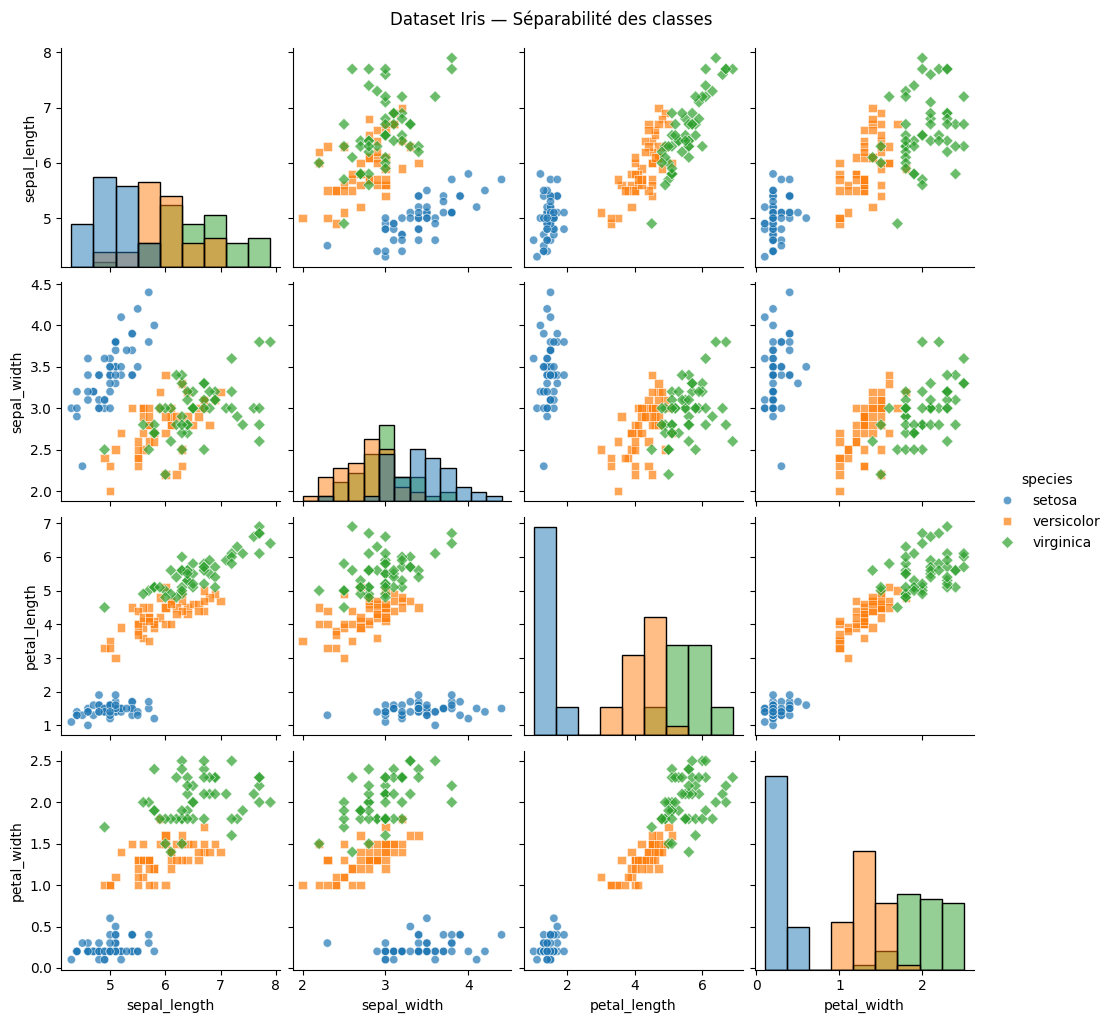

In [14]:
sns.pairplot(
    df,
    hue='species',
    markers=["o", "s", "D"],
    plot_kws=dict(alpha=0.7),
    diag_kind='hist'
)

plt.suptitle("Dataset Iris — Séparabilité des classes", y=1.02)
plt.savefig("iris_pairplot.png", bbox_inches="tight")
plt.show()

## Visualisation des données — Pairplot

Le pairplot permet de visualiser les relations entre les différentes variables du dataset ainsi que la séparation entre les classes.

### Observations

* L'espèce **setosa** est clairement séparée des deux autres.
  → Bleu
  → Les points bleus forment un groupe distinct, sans chevauchement.

* Les espèces **versicolor** et **virginica** sont plus proches.
  → Orange et vert
  → On observe un chevauchement partiel entre les points orange et verts.

* Les variables **petal_length** et **petal_width** permettent une meilleure séparation des classes.
  → Les groupes sont plus distincts sur ces axes.

* Les variables liées aux sépales (**sepal_length** et **sepal_width**) sont moins discriminantes.
  → Les points sont plus mélangés, donc moins utiles pour distinguer les espèces.

### Interprétation

* Plus les groupes sont séparés visuellement, plus il sera facile pour un modèle de classification de distinguer les classes.
* Ici, la classe **setosa** sera très facile à prédire.
* Les classes **versicolor** et **virginica** seront plus difficiles à distinguer.

### Conclusion

Le graphique confirme que certaines variables (notamment les pétales) sont plus importantes pour la classification.

→ Le modèle utilisera principalement ces variables pour faire ses prédictions.


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = le.fit_transform(df['species'])

feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

## Préparation des données (X et y)

Cette étape consiste à préparer les données pour l'entraînement du modèle.


### Création des variables

* **X** contient les variables explicatives (les caractéristiques des fleurs) :

  * `sepal_length`
  * `sepal_width`
  * `petal_length`
  * `petal_width`

* **y** contient la variable cible (ce que l’on veut prédire) :

  * l’espèce de la fleur (`species`)


### Encodage des classes

Le `LabelEncoder` transforme les valeurs texte en nombres :

* setosa → 0
* versicolor → 1
* virginica → 2

Cela est nécessaire car les modèles de machine learning travaillent avec des nombres et non du texte.

### feature_names

La variable `feature_names` contient les noms des variables utilisées dans le modèle.

Elle est utile pour :

* les graphiques
* l’interprétation des résultats (notamment avec SHAP)


### Remarque

Cette cellule ne produit pas de sortie visible car elle sert uniquement à préparer les données pour la suite du traitement.


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {len(X_train)} | Test : {len(X_test)}")

Train : 120 | Test : 30


## Séparation des données (Train / Test)

Cette étape consiste à diviser le dataset en deux parties :

* **Ensemble d'entraînement (train)** : utilisé pour apprendre au modèle
* **Ensemble de test (test)** : utilisé pour évaluer le modèle

### Répartition

* 80% des données → entraînement (120 échantillons)
* 20% des données → test (30 échantillons)

Cela permet de vérifier si le modèle est capable de généraliser sur de nouvelles données.

### Paramètres utilisés

* `test_size=0.2`
  → 20% des données sont utilisées pour le test

* `random_state=42`
  → permet d’obtenir toujours le même découpage (reproductibilité)

* `stratify=y`
  → garantit que chaque classe est bien représentée dans le train et le test
  (même proportion de setosa, versicolor, virginica)

### Pourquoi c’est important ?

Sans séparation train/test :

* le modèle pourrait apprendre par cœur
* impossible de savoir s’il fonctionne vraiment

Avec cette séparation :

* on teste le modèle sur des données qu’il n’a jamais vues
* on mesure sa capacité de généralisation

### Conclusion

Cette étape est essentielle pour construire un modèle fiable et éviter les erreurs d’apprentissage.


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

le = LabelEncoder()

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = le.fit_transform(df['species'])

feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Split entraînement/test (80%/20%) stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entraînement : {len(X_train)} échantillons | Test : {len(X_test)} échantillons")

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Baseline simple : Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_sc, y_train)

# Modèle principal : Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_sc, y_train)

print("Modèles entraînés.")

Entraînement : 120 échantillons | Test : 30 échantillons
Modèles entraînés.


## Explication du code

Ce bloc de code réalise plusieurs étapes pour préparer les données et entraîner des modèles de machine learning.

### Sélection des données

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

On récupère les variables explicatives (les mesures des fleurs)
`X` contient donc les caractéristiques des fleurs

y = le.fit_transform(df['species'])

On récupère la colonne `species` (espèce de la fleur)
On transforme les noms en nombres :

* setosa → 0
* versicolor → 1
* virginica → 2

### Séparation des données

X_train, X_test, y_train, y_test = train_test_split(...)

On découpe les données en deux parties :

* **train (80%)** → pour apprendre
* **test (20%)** → pour vérifier les performances

### Normalisation

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

On transforme les données pour qu’elles soient sur la même échelle
`_sc` signifie que les données sont normalisées

### Entraînement des modèles

dt = DecisionTreeClassifier(...)
dt.fit(X_train_sc, y_train)

On entraîne un **Decision Tree** (modèle simple)
Decision Tree : modèle simple basé sur des règles de décision


rf = RandomForestClassifier(...)
rf.fit(X_train_sc, y_train)

On entraîne un **Random Forest** (modèle plus puissant)
Random Forest : ensemble de plusieurs arbres de décision

Ces modèles proviennent de la bibliothèque scikit-learn.

### Fonctionnement des modèles

## Decision Tree

Le Decision Tree prend des décisions sous forme de règles
Exemple simplifié :

petal_length < 2 → setosa
sinon → autre classe

## Random Forest

Le Random Forest utilise plusieurs arbres :

chaque arbre fait une prédiction
les résultats sont combinés (vote)

### Méthodes utilisées

fit() : permet d’entraîner le modèle
→ le modèle apprend à associer les données aux bonnes réponses

predict() : permet de faire des prédictions sur de nouvelles données

### Objectif

Comparer un modèle simple (Decision Tree) avec un modèle plus complexe (Random Forest) afin d’évaluer leurs performances.

### Résultat

print("Modèles entraînés.")
Indique que l’entraînement s’est bien déroulé.

### Conclusion

Ce code :

- prépare les données
- les transforme
- entraîne deux modèles
- permet de comparer leurs performances

In [18]:
y_pred_dt = dt.predict(X_test_sc)
y_pred_rf = rf.predict(X_test_sc)

print("=== COMPARAISON BASELINE vs RANDOM FOREST ===")

for nom, pred in [("Decision Tree (baseline)", y_pred_dt), ("Random Forest", y_pred_rf)]:
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    print(f"{nom} → Accuracy : {acc*100:.1f}% | F1-score (weighted) : {f1:.3f}")

=== COMPARAISON BASELINE vs RANDOM FOREST ===
Decision Tree (baseline) → Accuracy : 96.7% | F1-score (weighted) : 0.967
Random Forest → Accuracy : 93.3% | F1-score (weighted) : 0.933


## Comparaison des modèles

Cette cellule compare les performances de deux modèles :

* Decision Tree (modèle simple)
* Random Forest (modèle plus complexe)

### Fonctionnement des modèles

#### Decision Tree

Le Decision Tree fonctionne comme une suite de règles de décision.

Exemple simplifié :

petal_length < 2 ?
    → oui → setosa
    → non → autre question

Le modèle apprend automatiquement ces règles à partir des données d’entraînement.

#### Random Forest

Le Random Forest est un ensemble de plusieurs arbres de décision :

* chaque arbre fait une prédiction
* les prédictions sont combinées (vote)
* la classe la plus votée est choisie

Cela permet généralement d’obtenir un modèle plus robuste.

### Apprentissage du modèle

Lors de l’appel à :
dt.fit(X_train_sc, y_train)

le modèle :

* analyse les données d’entrée (X)
* compare avec les réponses attendues (y)
* construit des règles pour relier les deux

Il apprend ainsi à associer les caractéristiques d’une fleur à son espèce.

### Résultats obtenus

* Decision Tree :

  * Accuracy : 96.7%
  * F1-score : 0.967

* Random Forest :

  * Accuracy : 93.3%
  * F1-score : 0.933

### Calcul des métriques

#### Accuracy

L’accuracy correspond au pourcentage de bonnes prédictions :

Accuracy = nombre de bonnes prédictions / nombre total

Exemple :

* 29 bonnes prédictions sur 30 → 96.7%

#### F1-score

Le F1-score combine deux mesures :

* la précision : qualité des prédictions
* le rappel : capacité à retrouver les bonnes classes

Il correspond à une moyenne équilibrée entre ces deux valeurs.

Plus le F1-score est proche de 1, plus le modèle est performant.

### Interprétation

Les deux modèles sont performants, mais le Decision Tree obtient ici de meilleurs résultats que le Random Forest.

Cela s’explique par le fait que le dataset Iris est relativement simple. Un modèle simple peut donc suffire à obtenir de très bonnes performances.

### Conclusion

* Les deux modèles donnent de bons résultats
* Le Decision Tree est légèrement meilleur dans ce cas
* Un modèle plus complexe n’est pas toujours plus performant
* Les métriques permettent d’évaluer objectivement les performances


=== RAPPORT DÉTAILLÉ — RANDOM FOREST ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



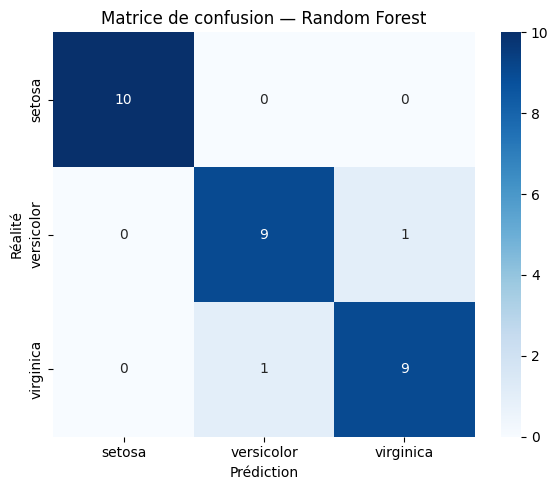

In [19]:
print("=== RAPPORT DÉTAILLÉ — RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Matrice de confusion — Random Forest")
plt.ylabel("Réalité")
plt.xlabel("Prédiction")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

## Matrice de confusion — Interprétation - Random Forest uniquement

La matrice de confusion permet de comparer les prédictions du modèle avec la réalité.

* Les lignes représentent les vraies classes (réalité)
* Les colonnes représentent les classes prédites

### Lecture de la matrice

* **setosa** :

  * 10 correctement classées
  * 0 erreur
    → classification parfaite

* **versicolor** :

  * 9 correctement classées
  * 1 erreur (prédite comme virginica)

* **virginica** :

  * 9 correctement classées
  * 1 erreur (prédite comme versicolor)

### Analyse des erreurs

Les erreurs concernent uniquement les classes :

* versicolor
* virginica

Cela s’explique par le fait que ces deux espèces ont des caractéristiques proches, ce qui rend leur distinction plus difficile.

### Interprétation globale

* Le modèle est très performant
* Toutes les fleurs setosa sont parfaitement reconnues
* Les erreurs sont rares et concernent uniquement des classes similaires

### Conclusion

La matrice de confusion confirme que le modèle fonctionne très bien.
Les erreurs observées sont logiques car certaines espèces sont difficiles à distinguer même visuellement.


In [20]:
from sklearn.model_selection import cross_val_score

n_estimators_range = [10, 25, 50, 100, 200, 500]
scores_cv = []

for n in n_estimators_range:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    cv = cross_val_score(m, X_train_sc, y_train, cv=5, scoring='accuracy')
    scores_cv.append(cv.mean())
    print(f"n_estimators={n} → CV accuracy : {cv.mean()*100:.1f}% (±{cv.std()*100:.1f}%)")

n_estimators=10 → CV accuracy : 95.8% (±0.0%)
n_estimators=25 → CV accuracy : 95.0% (±1.7%)
n_estimators=50 → CV accuracy : 95.0% (±1.7%)
n_estimators=100 → CV accuracy : 95.0% (±1.7%)
n_estimators=200 → CV accuracy : 95.0% (±1.7%)
n_estimators=500 → CV accuracy : 95.0% (±1.7%)


## Validation croisée (cross-validation)

Cette étape permet de tester la performance du modèle de manière plus fiable.

Au lieu de faire un seul test, les données d’entraînement sont découpées en plusieurs parties (ici 5).

Le modèle est entraîné et testé plusieurs fois, ce qui permet d’obtenir une moyenne de performance.

On teste ici différents nombres d’arbres (`n_estimators`) pour voir leur impact sur la précision.

Objectif : trouver le meilleur compromis entre performance et coût de calcul.

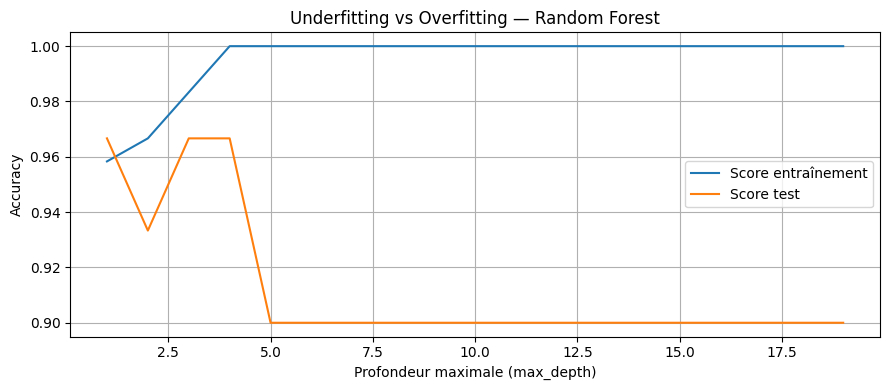

In [21]:
profondeurs = range(1, 20)
scores_train = []
scores_test = []

for d in profondeurs:
    m = RandomForestClassifier(n_estimators=50, max_depth=d, random_state=42)
    m.fit(X_train_sc, y_train)
    scores_train.append(m.score(X_train_sc, y_train))
    scores_test.append(m.score(X_test_sc, y_test))

plt.figure(figsize=(9, 4))
plt.plot(profondeurs, scores_train, label='Score entraînement')
plt.plot(profondeurs, scores_test, label='Score test')
plt.xlabel('Profondeur maximale (max_depth)')
plt.ylabel('Accuracy')
plt.title('Underfitting vs Overfitting — Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('overfitting.png')
plt.show()

## Overfitting et généralisation

Cette étape permet d’observer le comportement du modèle en fonction de sa complexité (profondeur des arbres).

* **Score entraînement** : performance sur les données utilisées pour apprendre
* **Score test** : performance sur de nouvelles données

### Interprétation

* Si les deux scores sont faibles → underfitting (modèle trop simple)
* Si le score train est élevé mais le score test plus faible → overfitting (modèle trop complexe)

### Objectif

Trouver une profondeur optimale :

* suffisamment complexe pour apprendre
* mais pas trop pour éviter le sur-apprentissage

### Conclusion

Le graphique permet de visualiser à partir de quel point le modèle commence à sur-apprendre.


/home/maeva-taite/Bureau/projet/ia/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


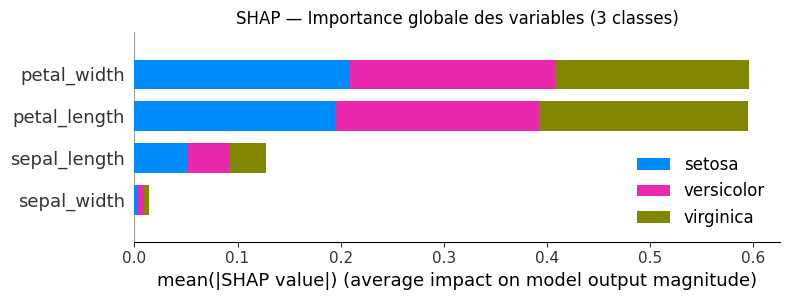

In [23]:
import shap

# Modèle final
rf_final = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_final.fit(X_train_sc, y_train)

# Explainer SHAP
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test_sc)

# Importance globale (barres)
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sc,
    feature_names=feature_names,
    class_names=list(le.classes_),
    plot_type='bar',
    show=False
)

plt.title("SHAP — Importance globale des variables (3 classes)")
plt.tight_layout()
plt.savefig("shap_summary.png")
plt.show()

## Explicabilité avec SHAP

SHAP permet de comprendre l’influence de chaque variable dans les prédictions du modèle.

### Principe

Pour chaque variable, SHAP calcule son importance dans la décision du modèle.

Cela permet de savoir :

* quelles variables sont les plus importantes
* comment elles influencent les prédictions

### Interprétation du graphique

Le graphique montre l’importance globale des variables :

* plus la barre est grande → plus la variable est importante

Dans ce cas, on observe généralement que :

* `petal_length` et `petal_width` sont les variables les plus importantes
* les variables liées aux sépales sont moins déterminantes

### Conclusion

Le modèle utilise principalement les caractéristiques des pétales pour distinguer les espèces.

Cela est cohérent avec les observations faites précédemment (pairplot).


## Synthèse — 3 insights clés

### Insight 1 — Performance

Observation :
Le Decision Tree obtient une accuracy de 96.7% et le Random Forest 93.3%.

Explication :
Le dataset Iris est simple et bien structuré, ce qui permet à un modèle simple d’obtenir d’excellentes performances.

Implication pratique :
Il est important de tester des modèles simples avant d’utiliser des modèles plus complexes.

### Insight 2 — Overfitting / Généralisation

Observation :
Le modèle peut sur-apprendre lorsque la profondeur des arbres augmente.

Explication :
Un modèle trop complexe mémorise les données d’entraînement au lieu de généraliser.

Implication pratique :
Il faut ajuster les hyperparamètres pour trouver un bon équilibre entre performance et généralisation.

### Insight 3 — Explicabilité

Observation :
Les variables `petal_length` et `petal_width` sont les plus importantes selon SHAP.

Explication :
Ces variables permettent de mieux distinguer les espèces, ce qui a déjà été observé visuellement.

Implication pratique :
Dans des contextes sensibles (santé, finance), il est essentiel de comprendre les décisions du modèle.
